<a href="https://colab.research.google.com/github/3realm/ML_Start/blob/main/Fraud_Solution2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

EDA. Просмотр файла. Анализ данных

# **00 Imports**

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving result_set.xlsx to result_set.xlsx


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

train = pd.read_excel("result_set.xlsx")
train.head()

,Ft 0,Ft 1,Ft 2,Ft 3,Ft 4,Ft 5,Ft 6,Ft 7,Ft 8,Ft 9,Ft 10,Ft 11,Ft 12,Ft 13,Ft14,Ft15,Ft16,Ft17,mark
0,1.620967,1.056248,0.114203,6.175593,5.625789,0.581535,7.360085,68,male,very_low,535.0,True,5,5,0,NaN,car,0,0
1,1.274494,0.814288,0.727210,3.606359,1.493780,7.810750,20.314335,24,female,high,846.0,False,3,1,1,quite rich,car,1,0
2,0.569931,1.607170,0.479581,3.521474,1.663726,2.297903,12.839282,67,male,high,782.0,False,0,0,0,moderate,furniture/equipment,1,0
3,0.547560,1.724393,0.682358,1.809472,10.149721,2.999319,49.108530,42,male,medium,132.0,False,3,3,0,quite rich,car,0,0
4,1.798884,1.748245,1.045646,1.560427,1.269053,1.403952,5.270951,84,male,very_low,708.0,False,0,0,0,NaN,radio/TV,1,0


# **01 Preprocessing**

In [ ]:
print("Shape:", train.shape)
print("\nInfo:")
train.info()

print("\nПропуски (top-10):")
print(train.isna().sum().sort_values(ascending=False).head(10))

Shape: (5000, 19)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 19 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Ft 0    5000 non-null   float64
 1   Ft 1    5000 non-null   float64
 2   Ft 2    5000 non-null   float64
 3   Ft 3    5000 non-null   float64
 4   Ft 4    5000 non-null   float64
 5   Ft 5    5000 non-null   float64
 6   Ft 6    5000 non-null   float64
 7   Ft 7    5000 non-null   int64  
 8   Ft 8    5000 non-null   object 
 9   Ft 9    5000 non-null   object 
 10  Ft 10   4936 non-null   float64
 11  Ft 11   4950 non-null   object 
 12  Ft 12   5000 non-null   int64  
 13  Ft 13   5000 non-null   int64  
 14  Ft14    5000 non-null   int64  
 15  Ft15    4183 non-null   object 
 16  Ft16    5000 non-null   object 
 17  Ft17    5000 non-null   int64  
 18  mark    5000 non-null   int64  
dtypes: float64(8), int64(6), object(5)
memory usage: 742.3+ KB

Пропуски (top-10):
Ft15   

In [ ]:
nunique_all = train.nunique(dropna=True).sort_values(ascending=False)
print("\nTop по nunique:")
display(nunique_all.head(18))



Top по nunique:


,0
Ft 0,5000
Ft 1,5000
Ft 2,5000
Ft 3,5000
Ft 4,5000
Ft 5,5000
Ft 6,5000
Ft 10,545
Ft 7,68
Ft16,8


Так, основные данные разобрали продожаем EDA:
- Разбивка по признакам
- Гистограммы
- Валидация  

In [ ]:
target = "mark"
X = train.drop(columns=[target])
y = train[target].astype(int)

print(f"Shape: X (features): {X.shape}")
print(f"Shape: Y (target): {y.shape}")


Shape: X (features): (5000, 18)
Shape: Y (target): (5000,)


Деление на числовые (int64, float64) и категориальные (object)
['Ft 12', 'Ft 13', 'Ft14', 'Ft17'] — имеют 2–7 уникальных значений - кактегориальные

In [ ]:
obj_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
num_cols = X.select_dtypes(include=["number"]).columns.tolist()
low_card_num = [c for c in num_cols if X[c].nunique(dropna=True) <= 20]

print("\nObject cols:", obj_cols)
print("Low-card numeric candidates (<=20):", low_card_num)


Object cols: ['Ft 8', 'Ft 9', 'Ft 11', 'Ft15', 'Ft16']
Low-card numeric candidates (<=20): ['Ft 12', 'Ft 13', 'Ft14', 'Ft17']


Пробуем делать преобразования:

In [ ]:
X = X.copy()

# Если Ft 11 не булева оставим как категорию
bool_col = "Ft 11"
if bool_col in X.columns:
    vals = set(X[bool_col].dropna().astype(str).str.lower().unique())
    bool_like = vals.issubset({"true", "false", "0", "1"})
    if bool_like:
        X[bool_col] = (
            X[bool_col]
            .replace({True: 1, False: 0, "True": 1, "False": 0, "true": 1, "false": 0, "1": 1, "0": 0})
        )
        X[bool_col] = pd.to_numeric(X[bool_col], errors="coerce")

        obj_cols = [c for c in obj_cols if c != bool_col]
        print("Ft 11 -> converted to numeric 0/1")
    else:
        print("Ft 11 оставлен как категория (не похоже на bool)")

cat_features = sorted(list(set(obj_cols + low_card_num)))
print("cat_features:", cat_features)

for c in low_card_num:
    if c in X.columns:
        X[c] = X[c].astype("Int64").astype(str)

for c in cat_features:
    if c in X.columns:
        X[c] = X[c].fillna("MISSING").astype(str)

print("\nMissing after preprocessing (top-10):")
print(X.isna().sum().sort_values(ascending=False).head(10))

Ft 11 оставлен как категория (не похоже на bool)
cat_features: ['Ft 12', 'Ft 13', 'Ft 8', 'Ft 9', 'Ft14', 'Ft15', 'Ft16', 'Ft17']

Missing after preprocessing (top-10):
Ft 10    64
Ft 11    50
Ft 1      0
Ft 0      0
Ft 2      0
Ft 3      0
Ft 6      0
Ft 7      0
Ft 4      0
Ft 5      0
dtype: int64


In [ ]:
# object-колонки + low-card числовые
cat_features = sorted(list(set(obj_cols + low_card_num)))
print("cat_features:", cat_features)

# low-card числовые
for c in low_card_num:
    if c in X.columns:
        X[c] = X[c].astype("Int64").astype(str)

# категории: fillna + str
for c in cat_features:
    if c in X.columns:
        X[c] = X[c].fillna("MISSING").astype(str)

print("\n dtypes of cat_features:")
display(X[cat_features].dtypes)

print("\n missing inside cat_features (should be 0):")
display(X[cat_features].isna().sum().sort_values(ascending=False).head(20))

print("\n nunique of cat_features:")
display(X[cat_features].nunique(dropna=True).sort_values(ascending=False))

cat_features: ['Ft 12', 'Ft 13', 'Ft 8', 'Ft 9', 'Ft14', 'Ft15', 'Ft16', 'Ft17']

 dtypes of cat_features:


,0
Ft 12,object
Ft 13,object
Ft 8,object
Ft 9,object
Ft14,object
Ft15,object
Ft16,object
Ft17,object



 missing inside cat_features (should be 0):


,0
Ft 12,0
Ft 13,0
Ft 8,0
Ft 9,0
Ft14,0
Ft15,0
Ft16,0
Ft17,0



 nunique of cat_features:


,0
Ft16,8
Ft 12,7
Ft 13,7
Ft15,5
Ft 9,4
Ft 8,2
Ft14,2
Ft17,2


ИТОГ:

CatBoost получит 8 категориальных признаков

они строковые, без NaN

кардинальность невысокая (меньше риск переобучения и быстрее обучение)

# **02 EDA**

Гистограмма

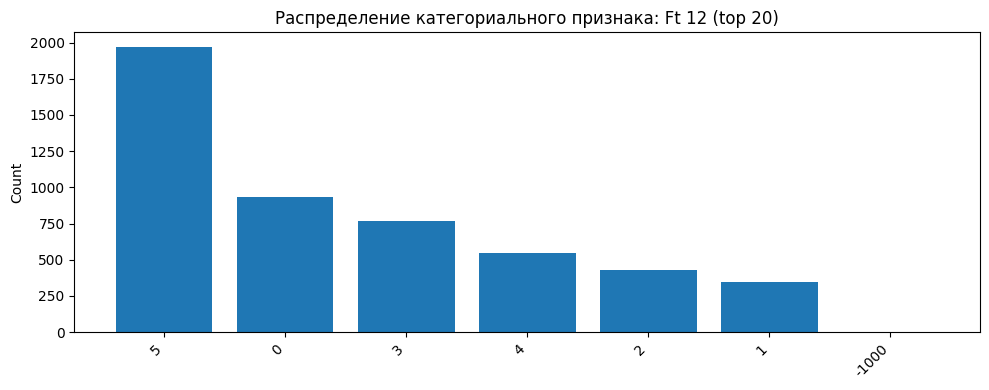

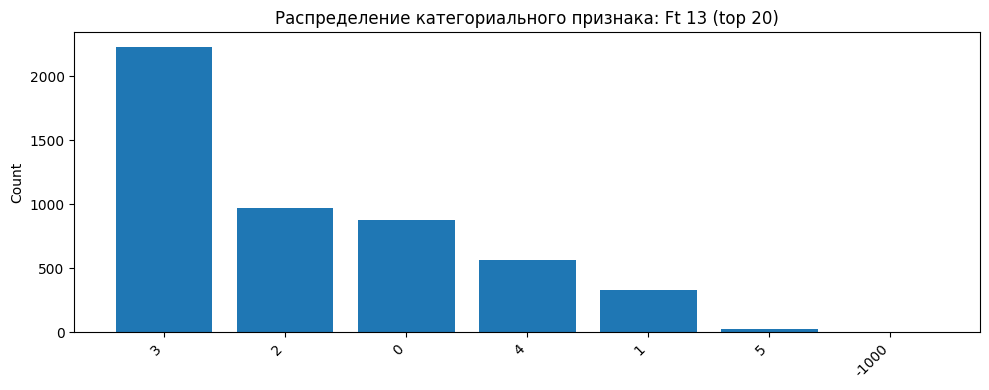

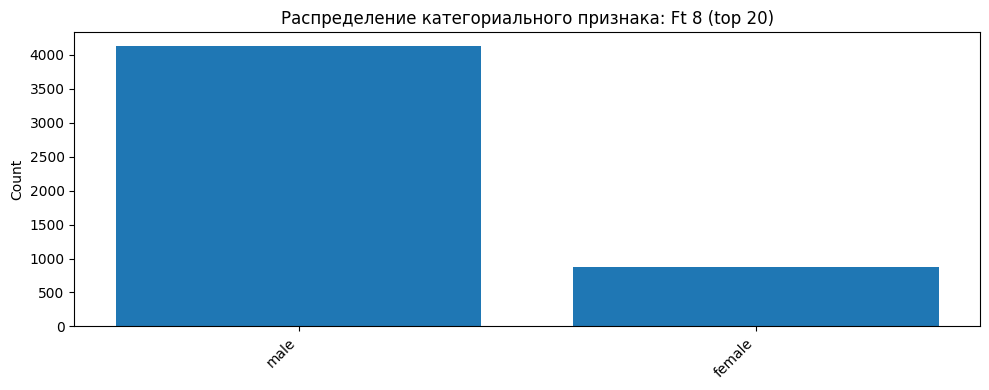

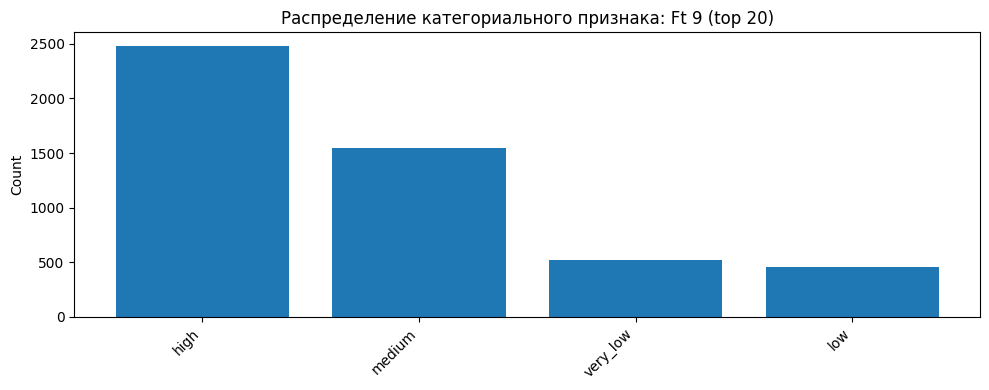

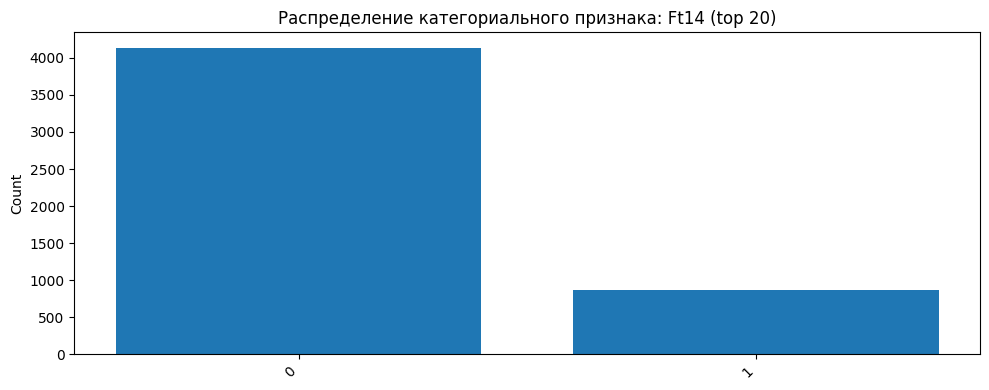

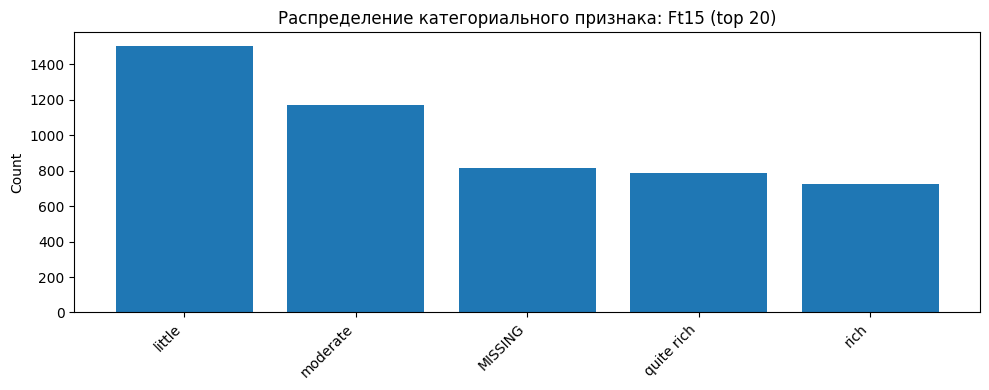

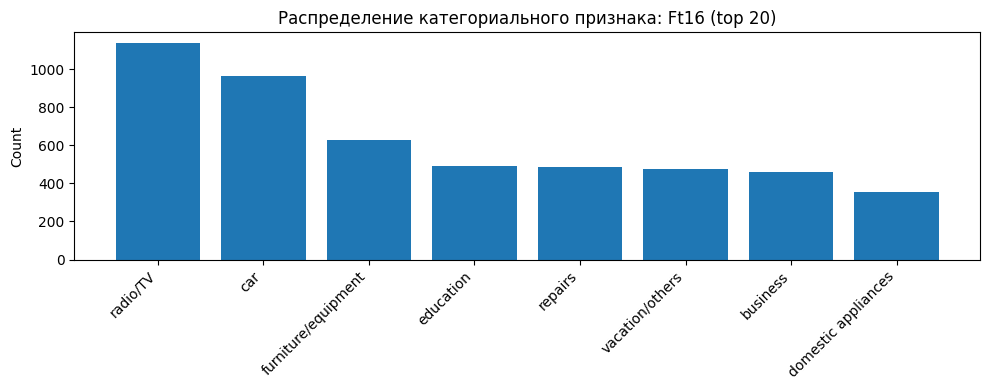

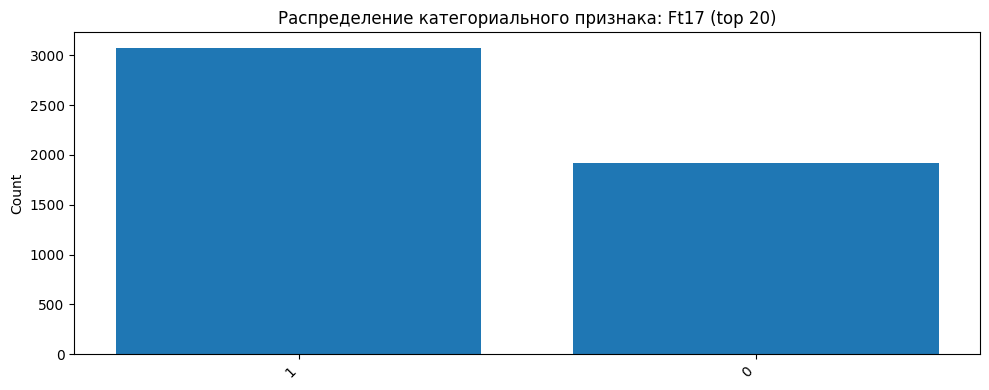

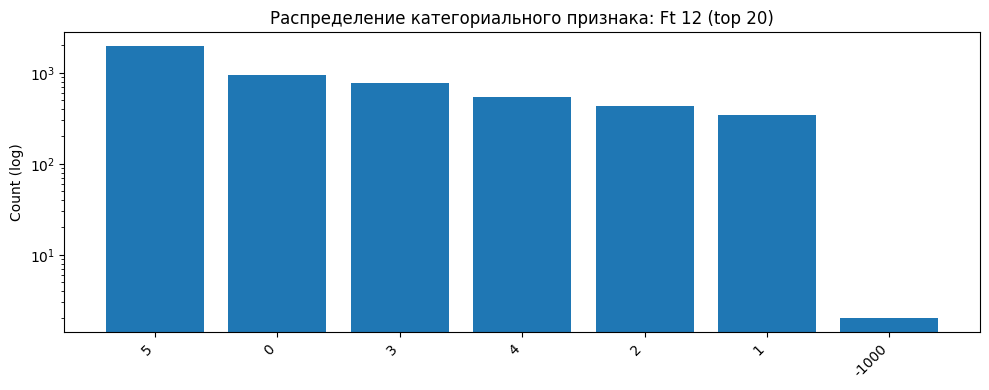

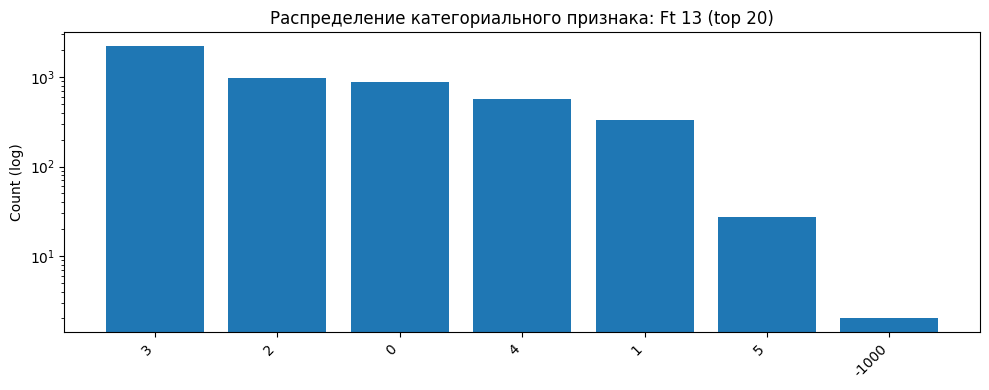

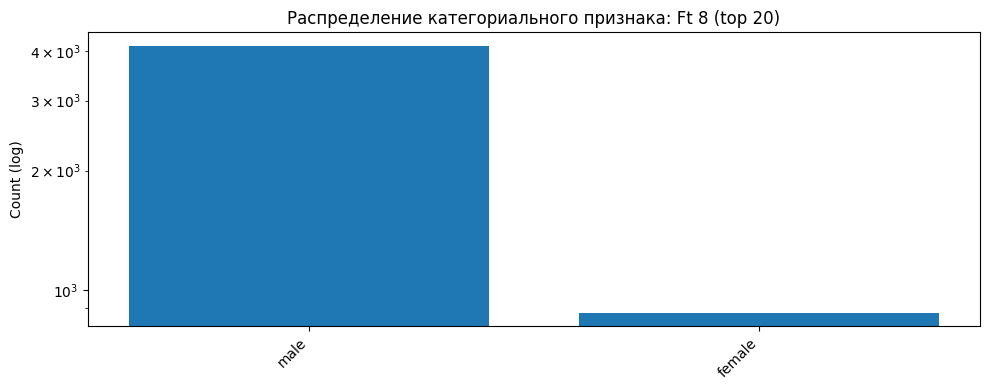

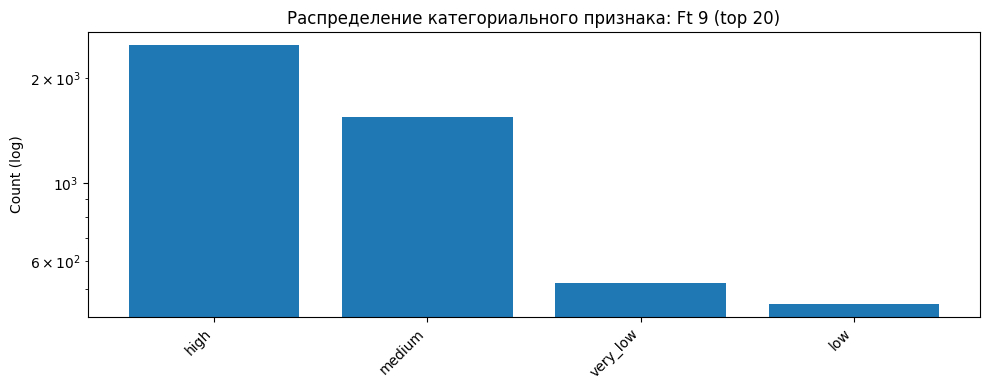

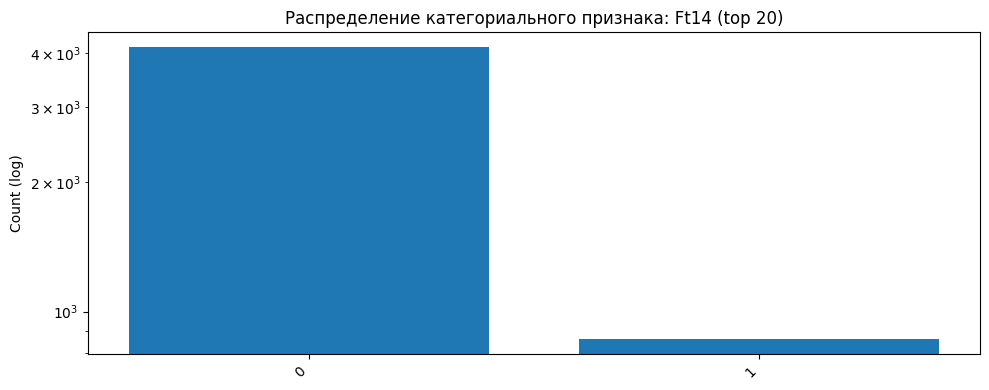

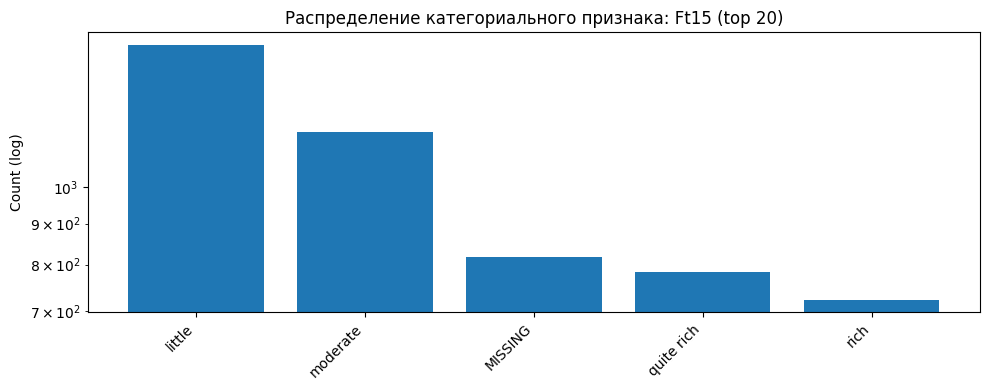

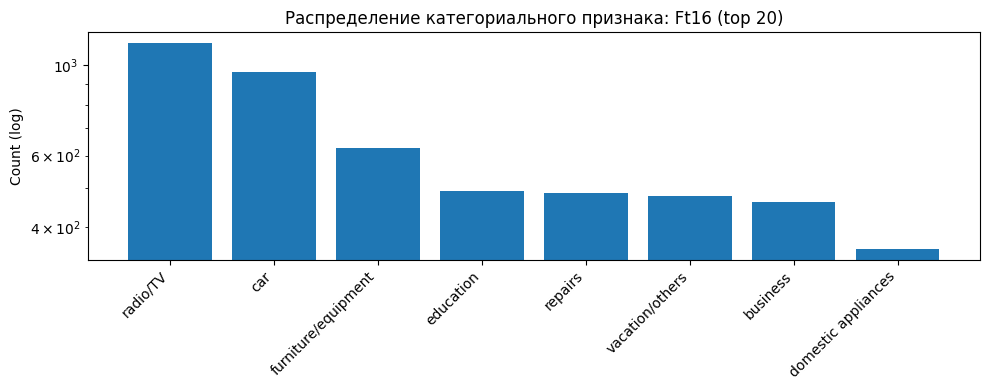

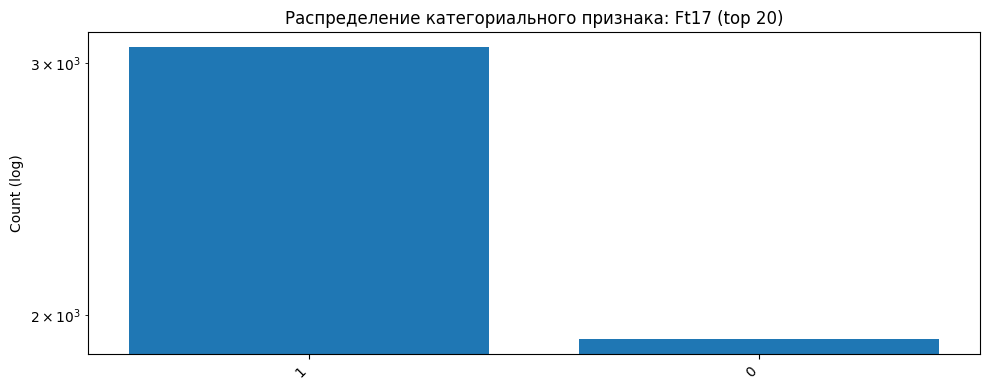

In [ ]:
import matplotlib.pyplot as plt
# Категориальные
def plot_categorical_distributions(X, cat_features, top_n=20, logy=False):
    for feature in cat_features:
        vc = X[feature].fillna("MISSING").astype(str).value_counts(dropna=False)

        if len(vc) > top_n:
            top = vc.iloc[:top_n]
            other = vc.iloc[top_n:].sum()
            vc_plot = pd.concat([top, pd.Series({"__OTHER__": other})])
        else:
            vc_plot = vc

        plt.figure(figsize=(10, 4))
        plt.bar(vc_plot.index.astype(str), vc_plot.values)
        plt.title(f"Распределение категориального признака: {feature} (top {top_n})")
        plt.ylabel("Count")
        if logy:
            plt.yscale("log")
            plt.ylabel("Count (log)")

        plt.xticks(rotation=45, ha="right")
        plt.tight_layout()
        plt.show()

plot_categorical_distributions(X, cat_features, top_n=20, logy=False)
plot_categorical_distributions(X, cat_features, top_n=20, logy=True)

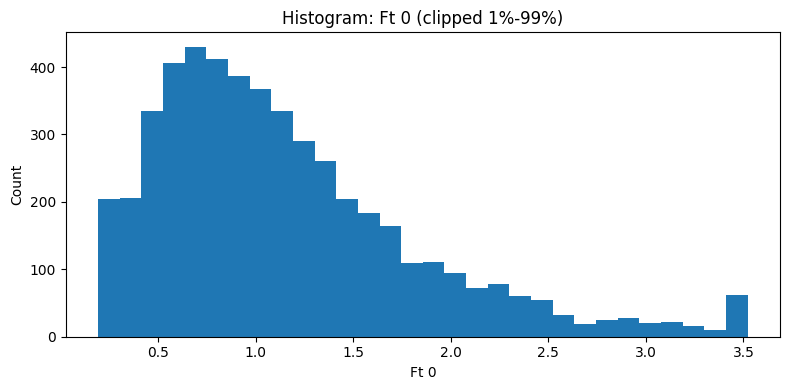

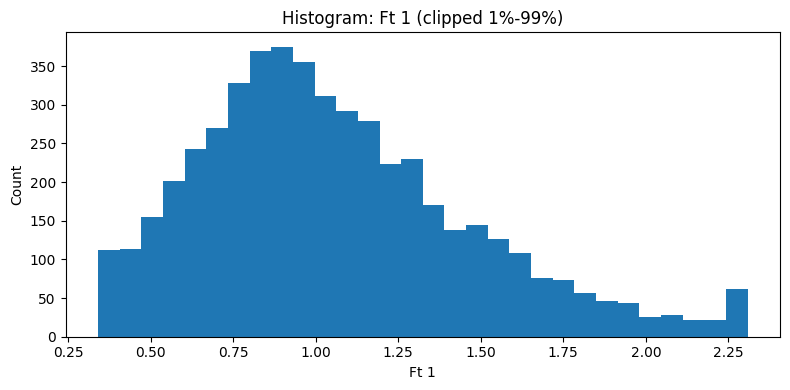

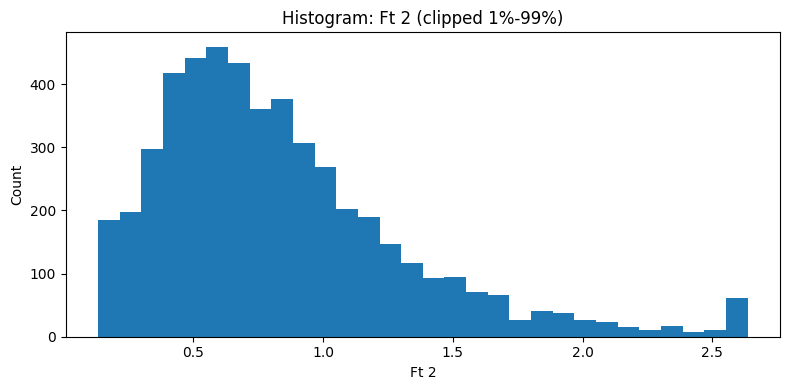

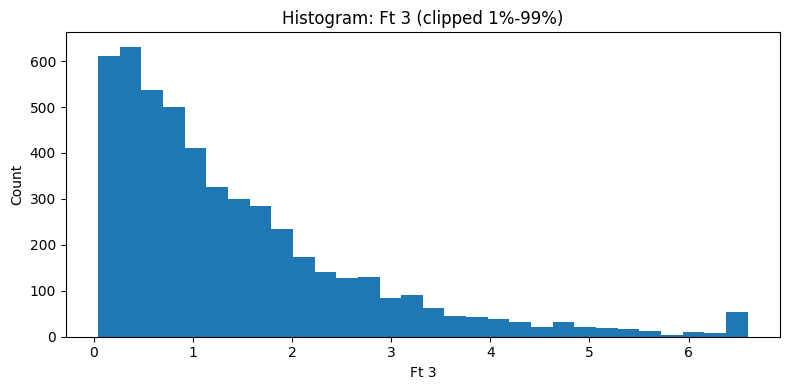

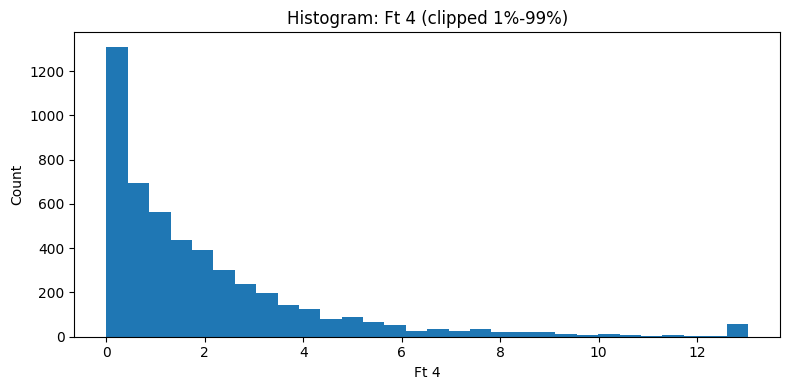

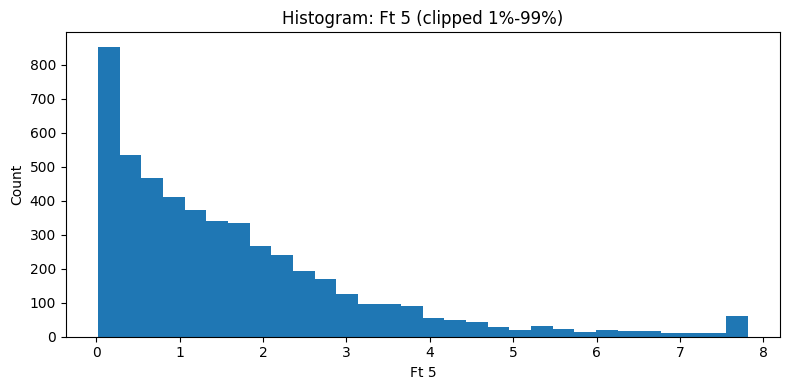

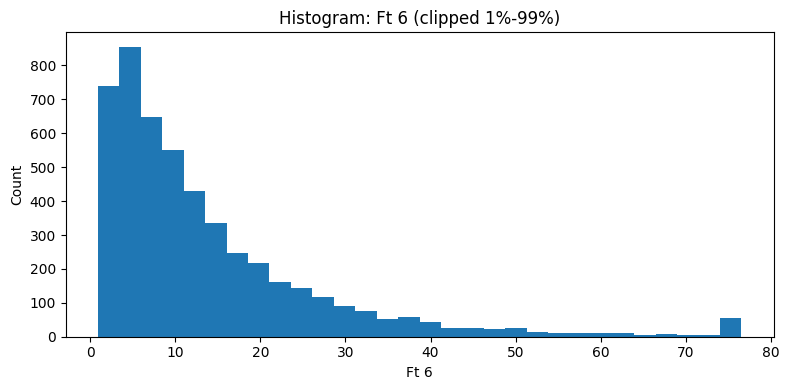

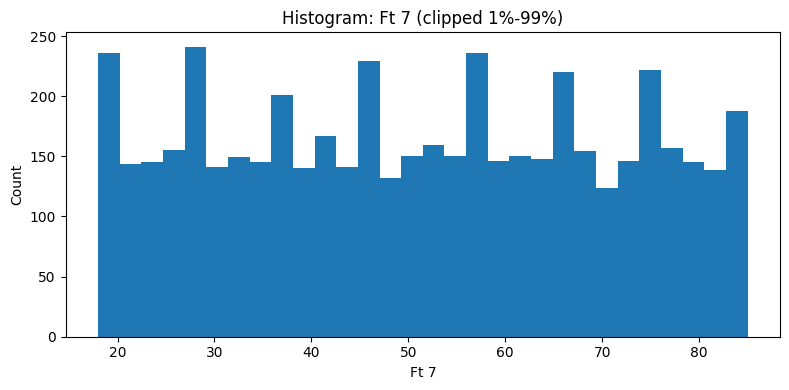

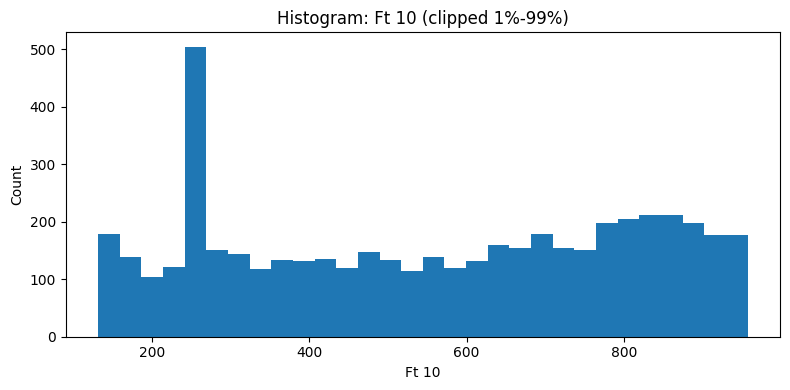

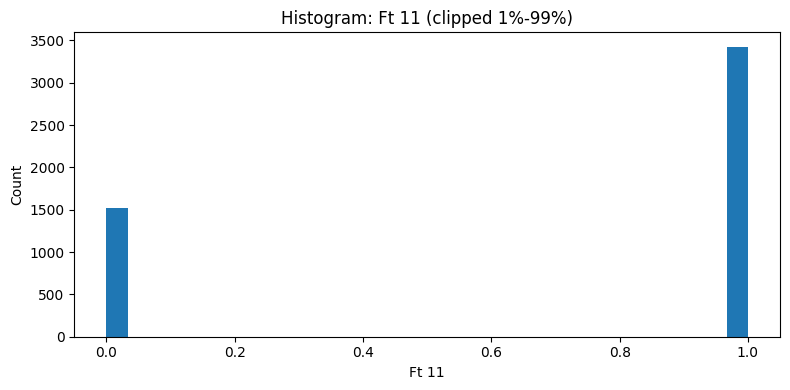

In [ ]:
# NUM
def plot_numeric_histograms(X, num_features, bins=30, clip_quantiles=(0.01, 0.99)):
    for feature in num_features:
        s = X[feature]

        # если всё NaN пропускаем
        if s.dropna().empty:
            print(f"Skip {feature}: all NaN")
            continue

        s_plot = s.copy()

        # клип по квантилям
        if clip_quantiles is not None:
            lo, hi = s_plot.quantile(clip_quantiles[0]), s_plot.quantile(clip_quantiles[1])
            s_plot = s_plot.clip(lo, hi)

        plt.figure(figsize=(8, 4))
        plt.hist(s_plot.dropna().values, bins=bins)
        ttl = f"Histogram: {feature}"
        if clip_quantiles is not None:
            ttl += f" (clipped {clip_quantiles[0]:.0%}-{clip_quantiles[1]:.0%})"
        plt.title(ttl)
        plt.xlabel(feature)
        plt.ylabel("Count")
        plt.tight_layout()
        plt.show()

num_features = X.select_dtypes(include=["number"]).columns.tolist()
plot_numeric_histograms(X, num_features, bins=30, clip_quantiles=(0.01, 0.99))

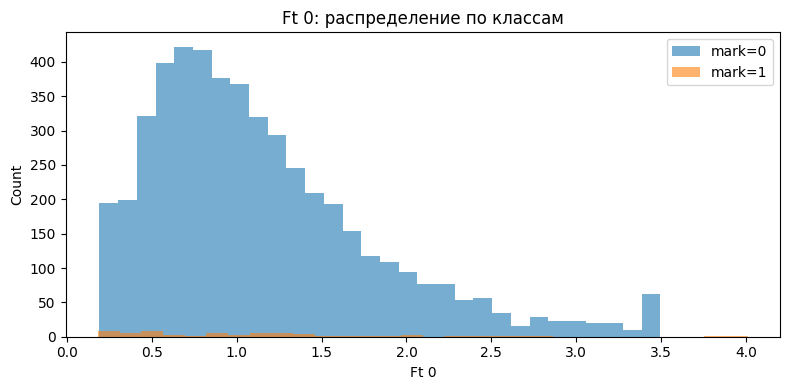

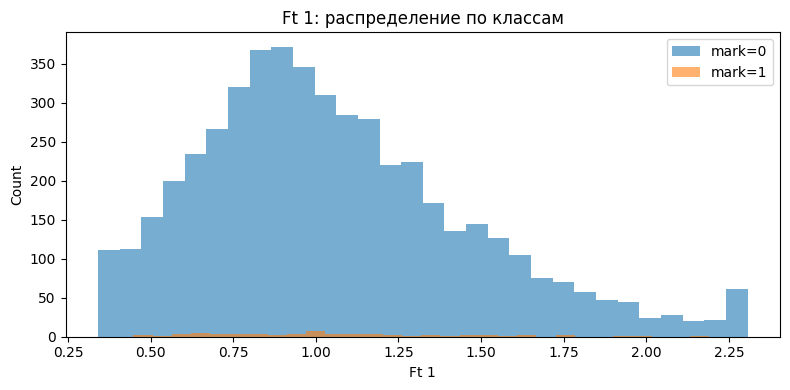

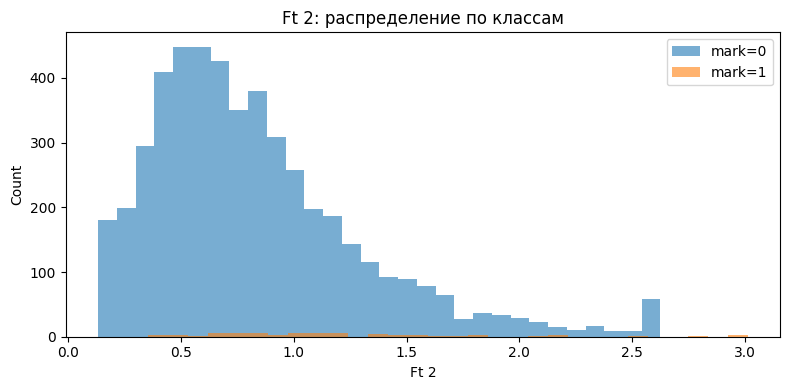

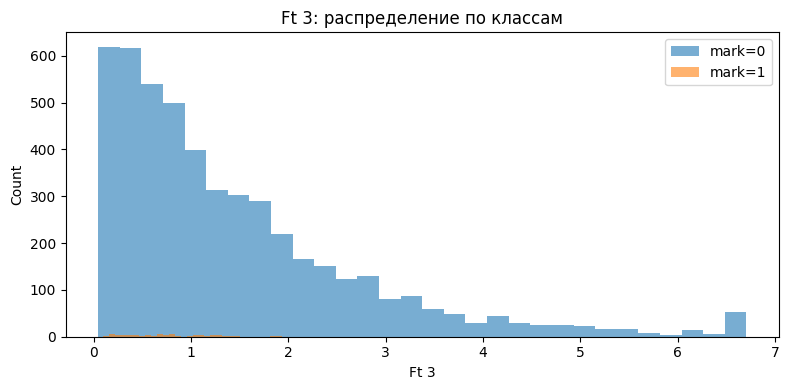

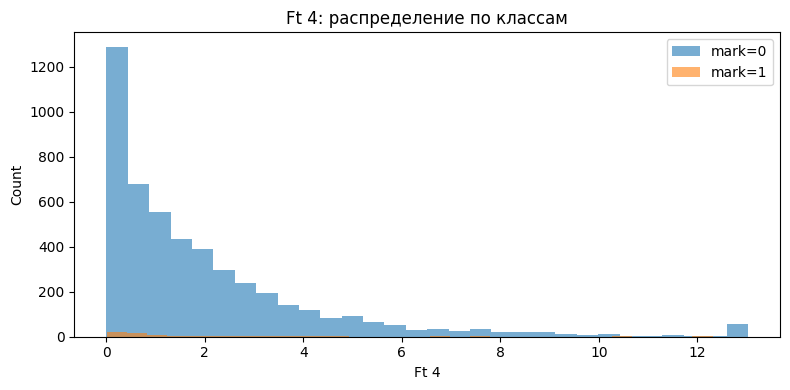

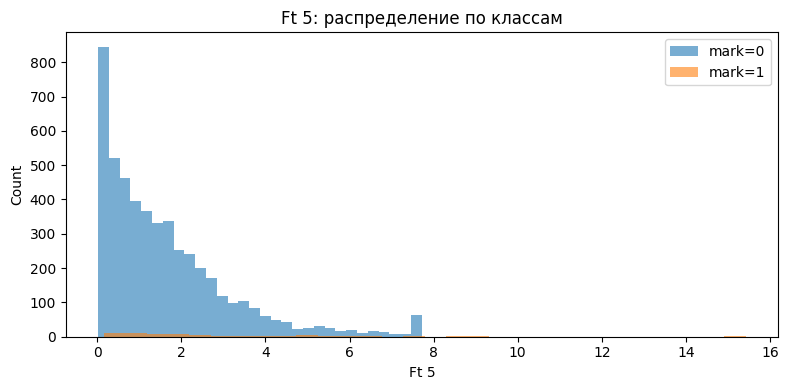

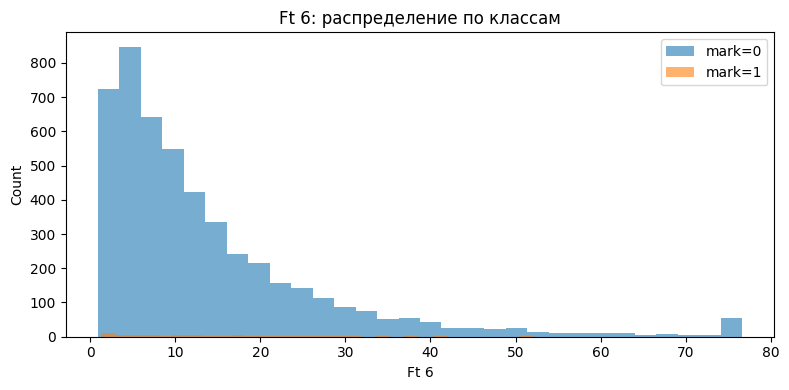

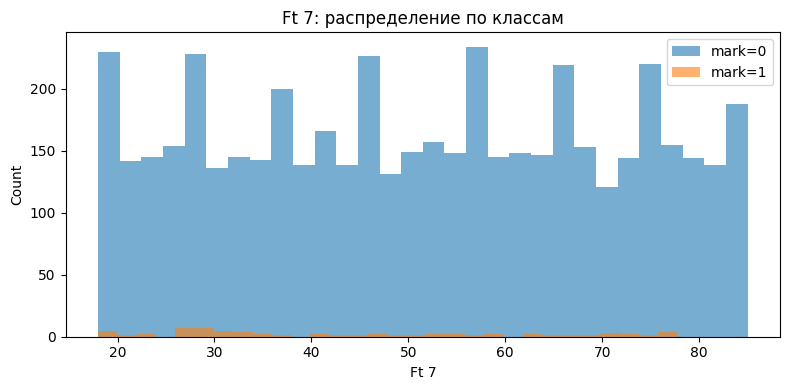

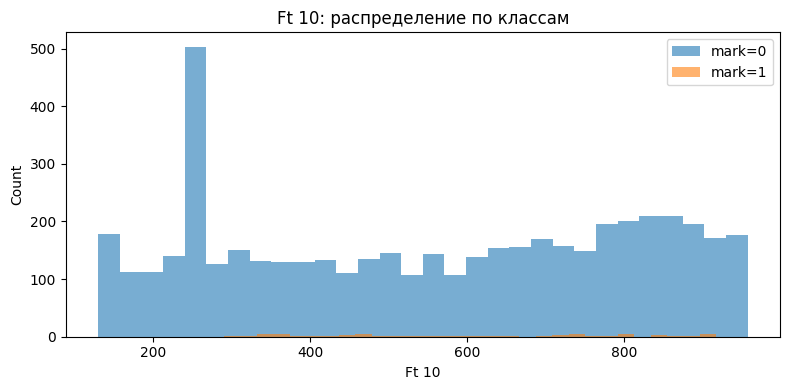

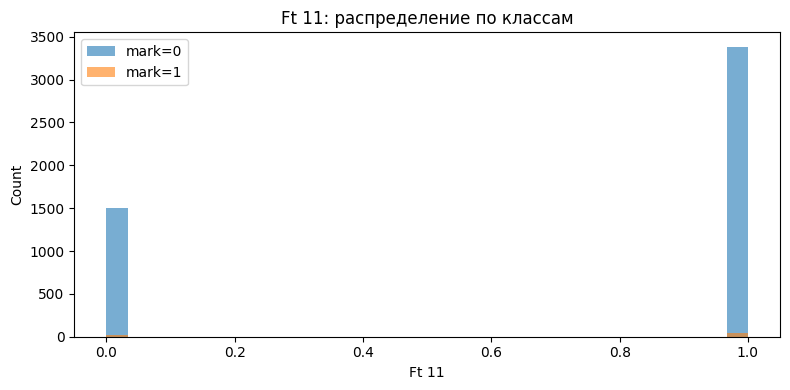

In [ ]:

def plot_numeric_by_target(X, y, num_features, bins=30, clip_quantiles=(0.01, 0.99)):
    for feature in num_features:
        s0 = X.loc[y == 0, feature]
        s1 = X.loc[y == 1, feature]

        if s0.dropna().empty and s1.dropna().empty:
            continue

        def prep(s):
            s = s.dropna()
            if s.empty:
                return s
            if clip_quantiles is not None:
                lo, hi = s.quantile(clip_quantiles[0]), s.quantile(clip_quantiles[1])
                s = s.clip(lo, hi)
            return s

        s0p, s1p = prep(s0), prep(s1)

        plt.figure(figsize=(8, 4))
        plt.hist(s0p.values, bins=bins, alpha=0.6, label="mark=0")
        plt.hist(s1p.values, bins=bins, alpha=0.6, label="mark=1")
        plt.title(f"{feature}: распределение по классам")
        plt.xlabel(feature)
        plt.ylabel("Count")
        plt.legend()
        plt.tight_layout()
        plt.show()

plot_numeric_by_target(X, y, num_features, bins=30, clip_quantiles=(0.01, 0.99))

получили следующее. Жесткий дисбаланс классов по mark: 0 - приоритетет

In [ ]:
counts = y.value_counts()
print(counts)
print("Positive rate (mark=1):", counts.get(1, 0) / len(y))
print("Neg/Pos ratio:", counts.get(0, 0) / max(counts.get(1, 1), 1))

mark
0    4936
1      64
Name: count, dtype: int64
Positive rate (mark=1): 0.0128
Neg/Pos ratio: 77.125


Валидация teest train split

In [ ]:
from sklearn.model_selection import train_test_split

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train:", X_train_full.shape, "Test:", X_test.shape)
print("Train positives:", int(y_train_full.sum()), "Test positives:", int(y_test.sum()))

Train: (4000, 18) Test: (1000, 18)
Train positives: 51 Test positives: 13


# **03 Final model + Test metrics**

In [ ]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.9 MB/s eta 0:00:00


In [ ]:

from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import (
    average_precision_score, roc_auc_score,
    precision_recall_curve, confusion_matrix, classification_report
)
from catboost import CatBoostClassifier, Pool

SEED = 42
N_SPLITS = 5

CB_PARAMS = dict(
    iterations=5000,
    learning_rate=0.03,
    depth=6,
    loss_function="Logloss",
    eval_metric="PRAUC",
    auto_class_weights="Balanced",
    random_seed=SEED,
    verbose=False,
    od_type="Iter",
    od_wait=200,
)

def cv_pr_auc(X_train, y_train, cat_features, n_splits=5, seed=42):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    rows = []

    for fold, (tr, va) in enumerate(skf.split(X_train, y_train), 1):
        X_tr, y_tr = X_train.iloc[tr], y_train.iloc[tr]
        X_va, y_va = X_train.iloc[va], y_train.iloc[va]

        train_pool = Pool(X_tr, y_tr, cat_features=cat_features)
        valid_pool = Pool(X_va, y_va, cat_features=cat_features)

        model = CatBoostClassifier(**CB_PARAMS)
        model.fit(train_pool, eval_set=valid_pool, use_best_model=True)

        proba_va = model.predict_proba(valid_pool)[:, 1]

        rows.append({
            "fold": fold,
            "pr_auc": average_precision_score(y_va, proba_va),
            "roc_auc": roc_auc_score(y_va, proba_va),
            "best_iter": model.get_best_iteration()
        })

    df = pd.DataFrame(rows)
    print("CV PR-AUC mean/std:", df["pr_auc"].mean(), df["pr_auc"].std())
    print("CV ROC-AUC mean/std:", df["roc_auc"].mean(), df["roc_auc"].std())
    print("CV best_iter mean:", df["best_iter"].mean())
    return df


def pick_threshold_by_precision(y_true, proba, target_precision=0.95):
    prec, rec, thr = precision_recall_curve(y_true, proba)
    prec2, rec2 = prec[:-1], rec[:-1]

    idx = np.where(prec2 >= target_precision)[0]
    if len(idx) == 0:
        return None, None

    best_i = idx[np.argmax(rec2[idx])]
    best_thr = thr[best_i]

    return best_thr, {"precision": prec2[best_i], "recall": rec2[best_i]}

baseline_ap = y_train_full.mean()
print("PR-AUC baseline (positive rate):", baseline_ap)

cv_df = cv_pr_auc(X_train_full, y_train_full, cat_features, n_splits=N_SPLITS, seed=SEED)
display(cv_df)

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_full, y_train_full,
    test_size=0.2,
    random_state=SEED,
    stratify=y_train_full
)

train_pool = Pool(X_tr, y_tr, cat_features=cat_features)
val_pool   = Pool(X_val, y_val, cat_features=cat_features)

model = CatBoostClassifier(**CB_PARAMS)
model.fit(train_pool, eval_set=val_pool, use_best_model=True, verbose=200)

proba_val = model.predict_proba(val_pool)[:, 1]
print("\nVAL PR-AUC :", average_precision_score(y_val, proba_val))
print("VAL ROC-AUC:", roc_auc_score(y_val, proba_val))


# Порог под “0 приоритет” выбираем на VAL, а не на TEST
target_precision = 0.95
thr, thr_stats = pick_threshold_by_precision(y_val, proba_val, target_precision=target_precision)

if thr is None:
    print("\nНе найден порог под precision >=", target_precision, "на VAL")
    chosen_thr = 0.5
else:
    chosen_thr = thr
    print("\nChosen threshold (from VAL):", chosen_thr)
    print("Precision:", thr_stats["precision"], "Recall:", thr_stats["recall"])



PR-AUC baseline (positive rate): 0.01275
CV PR-AUC mean/std: 0.3524281720163033 0.10400138163943498
CV ROC-AUC mean/std: 0.9066747700327138 0.03707670884465411
CV best_iter mean: 666.2


,fold,pr_auc,roc_auc,best_iter
0,1,0.437597,0.963924,838
1,2,0.392516,0.919873,151
2,3,0.360765,0.867089,683
3,4,0.172912,0.889873,1009
4,5,0.398351,0.892614,650


0:	learn: 0.7661439	test: 0.4325502	best: 0.4325502 (0)	total: 13ms	remaining: 1m 5s
200:	learn: 0.9996195	test: 0.9297124	best: 0.9436520 (161)	total: 1.6s	remaining: 38.1s
400:	learn: 1.0000000	test: 0.9403100	best: 0.9438781 (342)	total: 3.51s	remaining: 40.2s
Stopped by overfitting detector  (200 iterations wait)

bestTest = 0.9438780597
bestIteration = 342

Shrink model to first 343 iterations.

VAL PR-AUC : 0.5845888778525051
VAL ROC-AUC: 0.9424050632911393

Chosen threshold (from VAL): 0.6534356994085628
Precision: 1.0 Recall: 0.3


# **04 My Solution**

In [ ]:
test_pool = Pool(X_test, y_test, cat_features=cat_features)
proba_test = model.predict_proba(test_pool)[:, 1]

print("\nTEST PR-AUC :", average_precision_score(y_test, proba_test))
print("TEST ROC-AUC:", roc_auc_score(y_test, proba_test))

pred_test = (proba_test >= chosen_thr).astype(int)
print("\nConfusion matrix:\n", confusion_matrix(y_test, pred_test))
print("\nReport:\n", classification_report(y_test, pred_test, digits=4))


TEST PR-AUC : 0.34148012629631486
TEST ROC-AUC: 0.9609539396773439

Confusion matrix:
 [[986   1]
 [ 11   2]]

Report:
               precision    recall  f1-score   support

           0     0.9890    0.9990    0.9940       987
           1     0.6667    0.1538    0.2500        13

    accuracy                         0.9880      1000
   macro avg     0.8278    0.5764    0.6220      1000
weighted avg     0.9848    0.9880    0.9843      1000



# **Conclusions**

По метрикам ранжирования качество высокое: TEST ROC-AUC = 0.961 подтверждает сильное разделение классов, а TEST PR-AUC = 0.341 существенно выше базового уровня при таком дисбалансе модель действительно находит единицы заметно лучше случайного угадывания

Были попытки улучшать модель, но метрики на таких гиперпараметрах становились хуже

In [ ]:
# def train_one_split(X_train_full, y_train_full, cat_features, seed=42, fp_limit=1):
#     X_tr, X_val, y_tr, y_val = train_test_split(
#         X_train_full, y_train_full,
#         test_size=0.2, random_state=seed, stratify=y_train_full
#     )

#     train_pool = Pool(X_tr, y_tr, cat_features=cat_features)
#     val_pool   = Pool(X_val, y_val, cat_features=cat_features)

#     model = CatBoostClassifier(
#         iterations=5000,
#         learning_rate=0.03,
#         depth=6,
#         loss_function="Logloss",
#         eval_metric="AUC",
#         auto_class_weights="Balanced",
#         random_seed=seed,
#         verbose=False,
#         od_type="Iter",
#         od_wait=200,
#     )
#     model.fit(train_pool, eval_set=val_pool, use_best_model=True)

#     proba_val = model.predict_proba(val_pool)[:, 1]
#     pr = average_precision_score(y_val, proba_val)
#     roc = roc_auc_score(y_val, proba_val)

#     thresholds = np.unique(proba_val)
#     thresholds = np.r_[thresholds, 1.0]

#     best_thr = 1.0
#     best_tp = -1
#     best_cm = None

#     for thr in thresholds:
#         pred = (proba_val >= thr).astype(int)
#         tn, fp, fn, tp = confusion_matrix(y_val, pred).ravel()


#         if fp <= fp_limit:

#             if tp > best_tp:
#                 best_tp = tp
#                 best_thr = float(thr)
#                 best_cm = (tn, fp, fn, tp)

#
#     return {
#         "seed": seed,
#         "val_pr_auc": pr,
#         "val_roc_auc": roc,
#         "best_iter": model.get_best_iteration(),
#         "thr_fp_limit": best_thr,
#         "cm": best_cm,
#     }

# # 7) Повторяем несколько раз с разными random_state
# seeds = [10, 21, 42, 77, 123]
# fp_limit = 1   # 0 приоритет => стараемся не делать FP на val; если можно 1 FP, поставь 1

# rows = [train_one_split(X_train_full, y_train_full, cat_features, seed=s, fp_limit=fp_limit) for s in seeds]
# df = pd.DataFrame(rows)

# display(df[["seed","val_pr_auc","val_roc_auc","best_iter","thr_fp_limit","cm"]])

# print("VAL PR-AUC mean/std:", df["val_pr_auc"].mean(), df["val_pr_auc"].std())
# print("VAL ROC-AUC mean/std:", df["val_roc_auc"].mean(), df["val_roc_auc"].std())

# # 8) Берем устойчивые значения (медианы) для финального обучения
# chosen_thr = float(np.median(df["thr_fp_limit"]))
# chosen_iters = int(np.median(df["best_iter"]))

# print("Chosen threshold (median):", chosen_thr)
# print("Chosen iterations (median best_iter):", chosen_iters)

,seed,val_pr_auc,val_roc_auc,best_iter,thr_fp_limit,cm
0,10,0.409970,0.951772,449,0.270749,"(789, 1, 7, 3)"
1,21,0.364706,0.915570,84,0.731599,"(789, 1, 8, 2)"
2,42,0.496844,0.947215,161,0.674154,"(789, 1, 7, 3)"
3,77,0.219888,0.900506,158,0.701904,"(789, 1, 9, 1)"
4,123,0.062158,0.818608,552,0.495867,"(789, 1, 10, 0)"


VAL PR-AUC mean/std: 0.3107133163896362 0.1713481085029762
VAL ROC-AUC mean/std: 0.9067341772151899 0.05373610797026243
Chosen threshold (median): 0.6741542951007574
Chosen iterations (median best_iter): 161


SEED = 42 - самы лучший, сильно изменений в этом нет
Chosen threshold (median): 0.7919244092447458
Chosen iterations (median best_iter): 161

In [ ]:
# final_iters = 161
# chosen_thr = 0.7919244092447458

# final_model = CatBoostClassifier(
#     iterations=final_iters,
#     learning_rate=0.03,
#     depth=6,
#     loss_function="Logloss",
#     eval_metric="AUC",
#     auto_class_weights="Balanced",
#     random_seed=42,
#     verbose=200
# )

# train_pool = Pool(X_train_full, y_train_full, cat_features=cat_features)
# test_pool  = Pool(X_test, y_test, cat_features=cat_features)

# final_model.fit(train_pool)

# proba_test = final_model.predict_proba(test_pool)[:, 1]
# print("TEST PR-AUC:", average_precision_score(y_test, proba_test))
# print("TEST ROC-AUC:", roc_auc_score(y_test, proba_test))

# pred_test = (proba_test >= chosen_thr).astype(int)
# print("Confusion matrix:\n", confusion_matrix(y_test, pred_test))
# print(classification_report(y_test, pred_test, digits=4))

0:	total: 15.5ms	remaining: 2.48s
160:	total: 1.6s	remaining: 0us
TEST PR-AUC: 0.25358641297602436
TEST ROC-AUC: 0.9102953783804849
Confusion matrix:
 [[987   0]
 [ 12   1]]
              precision    recall  f1-score   support

           0     0.9880    1.0000    0.9940       987
           1     1.0000    0.0769    0.1429        13

    accuracy                         0.9880      1000
   macro avg     0.9940    0.5385    0.5684      1000
weighted avg     0.9881    0.9880    0.9829      1000

